In [39]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

epoch 0 loss = 0.046


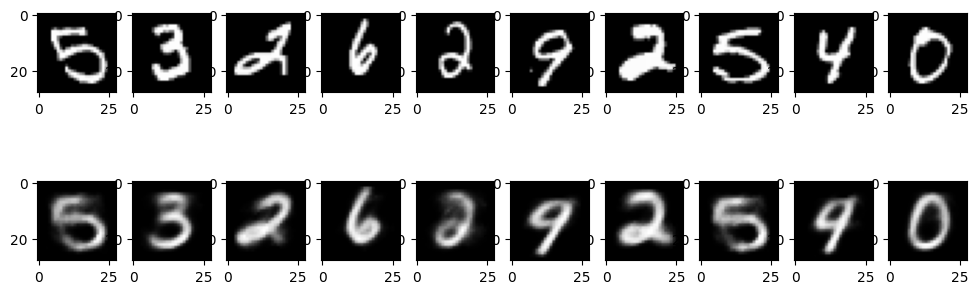

In [40]:
learning_rate=0.001
datasets=torchvision.datasets.MNIST(root='./data',train=True,transform=torchvision.transforms.ToTensor(),download=True)
data_loader=DataLoader(dataset=datasets,batch_size=100,shuffle=True)
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder,self).__init__()
        self.encoder=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,3)
        )
    
        self.decoder=nn.Sequential(
            nn.Linear(3,32),
            nn.ReLU(),
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
        )

    def forward(self,x):
        x=x.view(-1,28*28)
        x=self.encoder(x)
        x=self.decoder(x)
        x=x.view(-1,1,28,28)
        return x


model=Autoencoder()
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

num_epochs=10
for epoch in range(num_epochs):
    for data in data_loader:
        inputs,labels=data
        outputs=model(inputs)
        loss=criterion(inputs,outputs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 10 ==0:
       print(f"epoch {epoch} loss = {loss.item():.3f}")

with torch.no_grad():
    for data in data_loader:
        inputs,labels=data
        outputs=model(inputs)
        break
inputs=inputs.numpy()
outputs=outputs.numpy()
fig,axes=plt.subplots(2,10,figsize=(12,4))
for i in range(10):
    axes[0,i].imshow(inputs[i].squeeze(),cmap='gray')
    axes[1,i].imshow(outputs[i].squeeze(),cmap='gray')
plt.show()